In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cleaned_dataset1.csv to cleaned_dataset1.csv


In [ ]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML Models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Deep Learning (CNN)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
df = pd.read_csv('cleaned_dataset1.csv')

df.head()

,Rainfall_mm,Slope_Angle,Soil_Saturation,Vegetation_Cover,Rainfall_3Day,Rainfall_7Day,Earthquake_Activity,Proximity_to_Water,Soil_Type_Gravel,Soil_Type_Sand,Soil_Type_Silt,Soil_Type_Clay,Soil_Moisture_Content,Label
0,164.695364,59.783332,0.821479,0.107339,260.138381,79.297169,5.390869,0.847097,1,1,1,0,0.143732,1
1,34.908086,15.153084,0.100428,0.960150,510.295547,247.923576,3.554055,0.077767,0,1,0,1,0.266484,0
2,38.761727,13.135384,0.286526,0.833608,297.730266,194.327012,4.532214,0.157258,1,0,0,1,0.129426,0
3,32.199977,10.674734,0.255230,0.847569,231.640610,295.139546,3.069054,0.203603,1,1,1,0,0.240198,0
4,218.114032,48.839269,0.720071,0.018383,330.278249,301.288824,5.623601,0.984898,1,0,1,1,0.345724,1


In [ ]:
# Assume last column is target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "SVM": SVC(probability=True),
    "Gradient Boosting": GradientBoostingClassifier()
}

results = {}

In [ ]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    # Metrics
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    results[name] = {
        "model": model,
        "cm": cm,
        "fpr": fpr,
        "tpr": tpr,
        "auc": roc_auc,
        "f1": report['weighted avg']['f1-score']
    }

    print(f"\n{name}")
    print(classification_report(y_test, y_pred))


Logistic Regression
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       966
           1       0.98      0.97      0.98      1007

    accuracy                           0.98      1973
   macro avg       0.98      0.98      0.98      1973
weighted avg       0.98      0.98      0.98      1973


Random Forest
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       966
           1       0.98      0.97      0.98      1007

    accuracy                           0.98      1973
   macro avg       0.98      0.98      0.98      1973
weighted avg       0.98      0.98      0.98      1973


SVM
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       966
           1       0.98      0.97      0.98      1007

    accuracy                           0.98      1973
   macro avg       0.98      0.98      0.98      1973
weighted avg       0.98      0.98

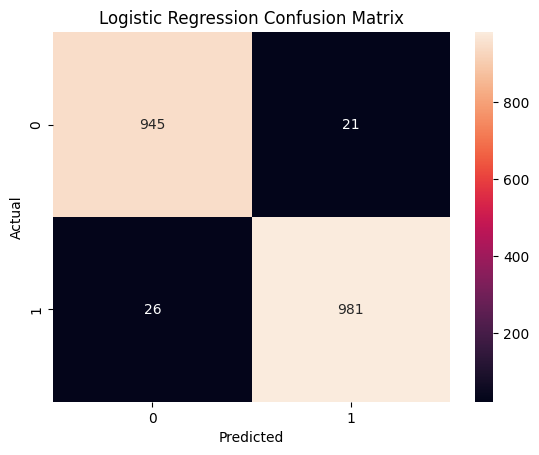

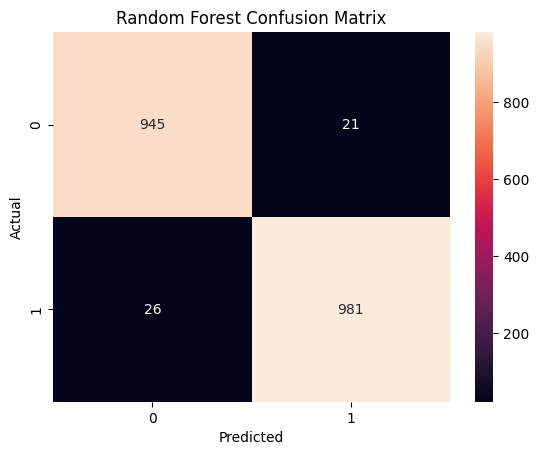

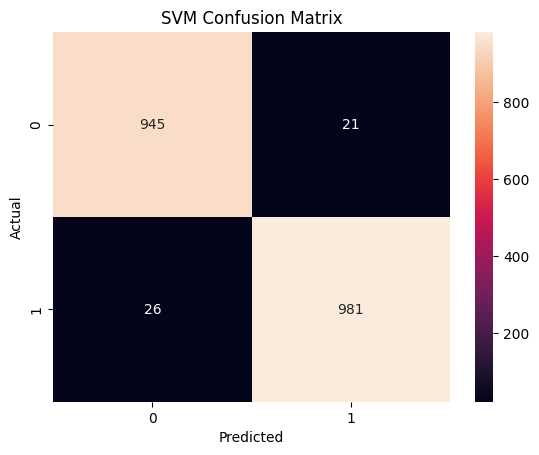

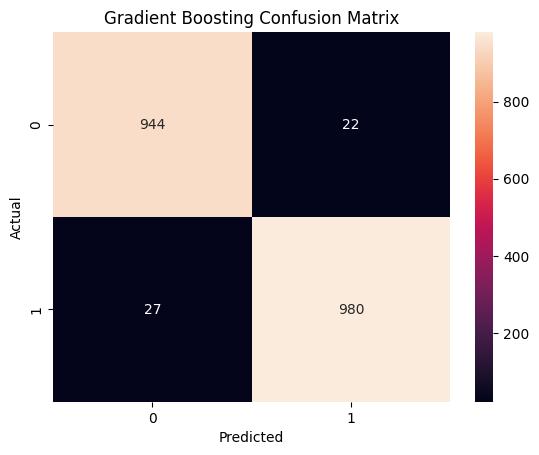

In [ ]:
for name in results:
    plt.figure()
    sns.heatmap(results[name]['cm'], annot=True, fmt='d')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

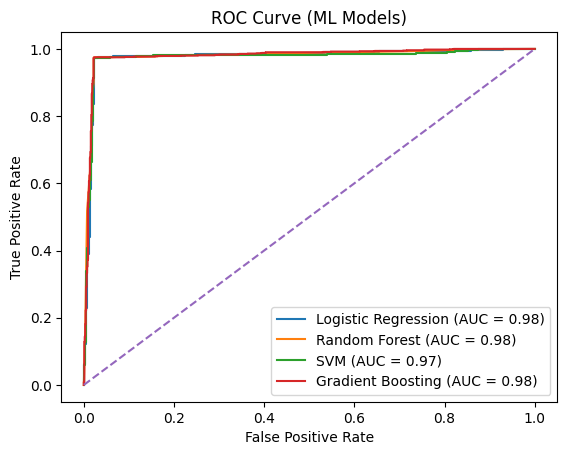

In [ ]:
plt.figure()

for name in results:
    plt.plot(results[name]['fpr'], results[name]['tpr'],
             label=f"{name} (AUC = {results[name]['auc']:.2f})")

plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve (ML Models)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [ ]:
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [ ]:
cnn = Sequential()

cnn.add(Conv1D(filters=64, kernel_size=2, activation='relu',
               input_shape=(X_train.shape[1],1)))
cnn.add(Dropout(0.3))

cnn.add(Conv1D(filters=32, kernel_size=2, activation='relu'))
cnn.add(Flatten())

cnn.add(Dense(64, activation='relu'))
cnn.add(Dense(1, activation='sigmoid'))

cnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = cnn.fit(
    X_train_cnn, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9604 - loss: 0.1862 - val_accuracy: 0.9709 - val_loss: 0.1336
Epoch 2/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9699 - loss: 0.1416 - val_accuracy: 0.9709 - val_loss: 0.1364
Epoch 3/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9699 - loss: 0.1414 - val_accuracy: 0.9709 - val_loss: 0.1318
Epoch 4/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9699 - loss: 0.1385 - val_accuracy: 0.9709 - val_loss: 0.1336
Epoch 5/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9699 - loss: 0.1388 - val_accuracy: 0.9709 - val_loss: 0.1317
Epoch 6/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9699 - loss: 0.1364 - val_accuracy: 0.9709 - val_loss: 0.1339
Epoch 7/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9699 - loss: 0.1381 - val_accuracy: 0.9709 - val_loss: 0.1347
Epoch 8/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9699 - loss: 0.1360 - val_accuracy: 0.

In [ ]:
y_pred_cnn = (cnn.predict(X_test_cnn) > 0.5).astype(int)

y_prob_cnn = cnn.predict(X_test_cnn)

cm_cnn = confusion_matrix(y_test, y_pred_cnn)
report_cnn = classification_report(y_test, y_pred_cnn, output_dict=True)

fpr_cnn, tpr_cnn, _ = roc_curve(y_test, y_prob_cnn)
auc_cnn = auc(fpr_cnn, tpr_cnn)

print(classification_report(y_test, y_pred_cnn))

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       966
           1       0.98      0.97      0.98      1007

    accuracy                           0.98      1973
   macro avg       0.98      0.98      0.98      1973
weighted avg       0.98      0.98      0.98      1973



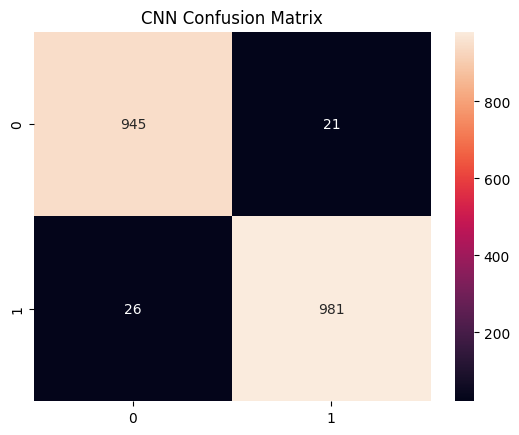

In [ ]:
plt.figure()
sns.heatmap(cm_cnn, annot=True, fmt='d')
plt.title("CNN Confusion Matrix")
plt.show()

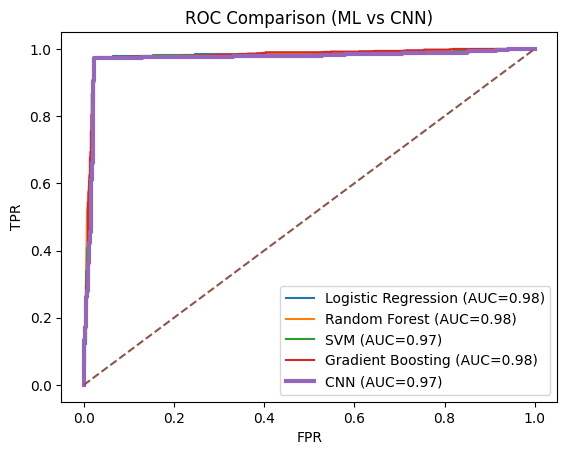

In [ ]:
plt.figure()

# ML models
for name in results:
    plt.plot(results[name]['fpr'], results[name]['tpr'],
             label=f"{name} (AUC={results[name]['auc']:.2f})")

# CNN
plt.plot(fpr_cnn, tpr_cnn, label=f"CNN (AUC={auc_cnn:.2f})", linewidth=3)

plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Comparison (ML vs CNN)")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

In [ ]:
comparison = []

for name in results:
    comparison.append({
        "Model": name,
        "F1 Score": results[name]['f1'],
        "AUC": results[name]['auc']
    })

comparison.append({
    "Model": "CNN",
    "F1 Score": report_cnn['weighted avg']['f1-score'],
    "AUC": auc_cnn
})

pd.DataFrame(comparison)

,Model,F1 Score,AUC
0,Logistic Regression,0.976180,0.976224
1,Random Forest,0.976180,0.978179
2,SVM,0.976180,0.974317
3,Gradient Boosting,0.975166,0.979038
4,CNN,0.976180,0.970166


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced',
                               classes=classes,
                               y=y_train)

class_weights = {i: weights[i] for i in range(len(weights))}

print(class_weights)

{0: np.float64(1.0016501650165017), 1: np.float64(0.9983552631578947)}


In [ ]:
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [ ]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

cnn = Sequential()

# Block 1
cnn.add(Conv1D(128, kernel_size=2, activation='relu',
               input_shape=(X_train.shape[1],1)))
cnn.add(BatchNormalization())
cnn.add(Dropout(0.3))

# Block 2
cnn.add(Conv1D(64, kernel_size=2, activation='relu'))
cnn.add(BatchNormalization())
cnn.add(Dropout(0.3))

# Block 3
cnn.add(Conv1D(32, kernel_size=2, activation='relu'))
cnn.add(BatchNormalization())

cnn.add(Flatten())

# Dense layers
cnn.add(Dense(128, activation='relu'))
cnn.add(Dropout(0.4))

cnn.add(Dense(64, activation='relu'))

cnn.add(Dense(1, activation='sigmoid'))

cnn.compile(
    optimizer=Adam(learning_rate=0.0005),  # lower LR = better stability
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

history = cnn.fit(
    X_train_cnn, y_train,
    epochs=50,                 # more learning
    batch_size=16,             # smaller batch = better generalization
    validation_split=0.2,
    class_weight=class_weights,  # 🔥 KEY for FP/FN
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9509 - loss: 0.1941 - val_accuracy: 0.9709 - val_loss: 0.1565 - learning_rate: 5.0000e-04
Epoch 2/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9697 - loss: 0.1551 - val_accuracy: 0.9709 - val_loss: 0.1335 - learning_rate: 5.0000e-04
Epoch 3/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9699 - loss: 0.1521 - val_accuracy: 0.9709 - val_loss: 0.1332 - learning_rate: 5.0000e-04
Epoch 4/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9699 - loss: 0.1450 - val_accuracy: 0.9709 - val_loss: 0.1427 - learning_rate: 5.0000e-04
Epoch 5/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9699 - loss: 0.1444 - val_accuracy: 0.9709 - val_loss: 0.1334 - learning_rate: 5.0000e-04
Epoch 6/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9699 - loss: 0.1380 - val_accuracy: 0.9709 - val_loss: 0.1340 - learning_rate: 5.0000e-04
Epoch 7/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 

In [ ]:
from sklearn.metrics import f1_score

y_probs = cnn.predict(X_test_cnn)

thresholds = np.arange(0.3, 0.7, 0.01)
best_thresh = 0.5
best_f1 = 0

for t in thresholds:
    y_pred_temp = (y_probs > t).astype(int)
    score = f1_score(y_test, y_pred_temp)

    if score > best_f1:
        best_f1 = score
        best_thresh = t

print("Best Threshold:", best_thresh)

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Best Threshold: 0.3


In [ ]:
y_pred_cnn = (y_probs > best_thresh).astype(int)

from sklearn.metrics import confusion_matrix, classification_report

cm_cnn = confusion_matrix(y_test, y_pred_cnn)
report_cnn = classification_report(y_test, y_pred_cnn)

print(report_cnn)

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       966
           1       0.98      0.97      0.98      1007

    accuracy                           0.98      1973
   macro avg       0.98      0.98      0.98      1973
weighted avg       0.98      0.98      0.98      1973



In [ ]:
from sklearn.metrics import roc_curve, auc

fpr_cnn, tpr_cnn, _ = roc_curve(y_test, y_probs)
auc_cnn = auc(fpr_cnn, tpr_cnn)

print("CNN AUC:", auc_cnn)

CNN AUC: 0.9712385969024283


In [ ]:
from sklearn.metrics import roc_curve, auc

fpr_cnn, tpr_cnn, _ = roc_curve(y_test, y_probs)
auc_cnn = auc(fpr_cnn, tpr_cnn)

print("CNN AUC:", auc_cnn)

CNN AUC: 0.9712385969024283


In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf.fit(X_train, y_train)

rf_probs = rf.predict_proba(X_test)[:,1]

In [ ]:
cnn_probs = cnn.predict(X_test_cnn).flatten()

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
# Adjust weights if needed
w_cnn = 0.6
w_rf = 0.4

ensemble_probs = (w_cnn * cnn_probs) + (w_rf * rf_probs)

In [ ]:
from sklearn.metrics import f1_score
import numpy as np

thresholds = np.arange(0.3, 0.7, 0.01)

best_thresh = 0.5
best_f1 = 0

for t in thresholds:
    preds = (ensemble_probs > t).astype(int)
    score = f1_score(y_test, preds)

    if score > best_f1:
        best_f1 = score
        best_thresh = t

print("Best Threshold:", best_thresh)
print("Best F1:", best_f1)

Best Threshold: 0.3
Best F1: 0.9766052762568442


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

y_pred_ens = (ensemble_probs > best_thresh).astype(int)

# Confusion Matrix
cm_ens = confusion_matrix(y_test, y_pred_ens)

# Report
print(classification_report(y_test, y_pred_ens))

# ROC
fpr_ens, tpr_ens, _ = roc_curve(y_test, ensemble_probs)
auc_ens = auc(fpr_ens, tpr_ens)

print("Ensemble AUC:", auc_ens)

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       966
           1       0.98      0.97      0.98      1007

    accuracy                           0.98      1973
   macro avg       0.98      0.98      0.98      1973
weighted avg       0.98      0.98      0.98      1973

Ensemble AUC: 0.9731650701816065


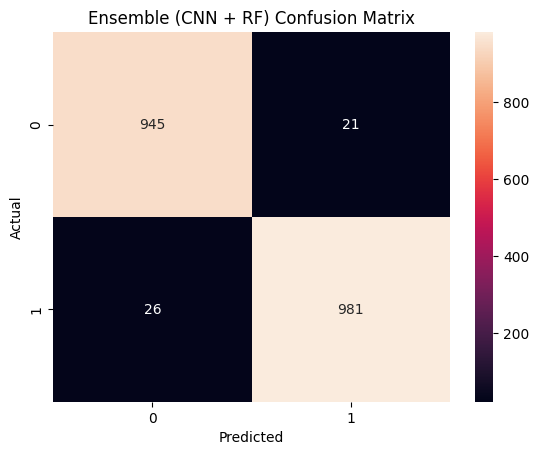

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.heatmap(cm_ens, annot=True, fmt='d')
plt.title("Ensemble (CNN + RF) Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

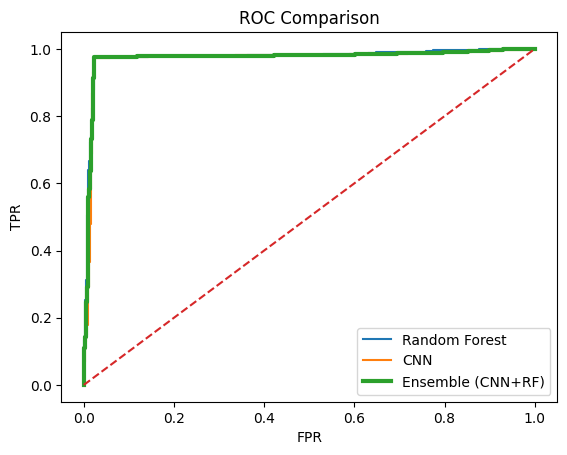

In [ ]:
plt.figure()

# RF
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
plt.plot(fpr_rf, tpr_rf, label="Random Forest")

# CNN
plt.plot(fpr_cnn, tpr_cnn, label="CNN")

# Ensemble
plt.plot(fpr_ens, tpr_ens, linewidth=3, label="Ensemble (CNN+RF)")

plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Comparison")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()